In [1]:
#imports and initializations
import numpy as np
import os
import pandas as pd
import datetime
import tifffile
import functools
from torchvision.io import decode_image
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import torchvision

LR_COL_NAME = "lr_name"
HR_COL_NAME = "hr_name"
DSET_DIR = "dset_out"
LR_DIR = "lr_files"
HR_DIR = "hr_files"
can_cuda = torch.cuda.is_available()
if can_cuda:
    device = "cuda"
else: 
    device = "cpu"
print(device)

CMAP = 'gray'

cuda


In [2]:

#class and helper function definition
#adapted from: https://github.com/xinntao/ESRGAN/blob/master/RRDBNet_arch.py
#https://github.com/XPixelGroup/BasicSR/blob/master/basicsr/models/realesrgan_model.py

class ResidualDenseBlock_3C(nn.Module):
    def __init__(self, nf=64, gc=32, bias=True, r_scale=0.2):
        super(ResidualDenseBlock_3C, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=nf, out_channels=gc, kernel_size=3, padding=1, stride=1, bias=bias)
        self.conv2 = nn.Conv2d(nf + gc, gc, 3, 1, 1, bias=bias)
        self.conv3 = nn.Conv2d(nf + 2*gc, nf, 3, 1, 1, bias=bias)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)
        self.r_scale = r_scale
    
    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.concat([x, x1],1)))
        x3 = self.lrelu(self.conv3(torch.concat([x, x1, x2],1)))
        return x3 * self.r_scale + x #SR is a task that is close to unity. We want to scale residuals and add them back to the path
    

class RRDB(nn.Module):
    def __init__(self, nf, gc, bias, r_scale):
        super(RRDB, self).__init__()
        self.rdb1 = ResidualDenseBlock_3C(nf, gc, bias, r_scale)
        self.rdb2 = ResidualDenseBlock_3C(nf, gc, bias, r_scale)
        self.rdb3 = ResidualDenseBlock_3C(nf, gc, bias, r_scale)
        self.r_scale = r_scale

    def forward(self, x):
        out = self.rdb1(x)
        out = self.rdb2(x)
        out = self.rdb3(x)
        return out * self.r_scale + x

class RRDB_Generator(nn.Module):
    def __init__(self, in_nc: int, nf: int, gc: int, bias: bool, r_scale: float, out_nc: int):
        super(RRDB_Generator, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=in_nc, out_channels=nf, kernel_size=9, padding=4, stride=1, bias=bias)
        self.prelu1 = nn.PReLU()
        self.rrdb = RRDB(nf, gc, bias, r_scale)
        self.conv2 = nn.Conv2d(in_channels=nf, out_channels=nf, kernel_size=3, padding=1, stride=1, bias=bias)
        #need to up scale by 8x, do 4 then 2
        self.conv_pix1 = nn.Conv2d(in_channels=nf, out_channels=256, kernel_size=3, padding=1, stride=1, bias=bias)
        self.pixel_shift1 = nn.PixelShuffle(2)
        self.prelu2 = nn.PReLU()
        #channels shrink by scale factor squared
        self.conv_pix2 = nn.Conv2d(in_channels=nf, out_channels=256, kernel_size=3, padding=1, stride=1, bias=bias)
        self.pixel_shift2 = nn.PixelShuffle(2)
        self.prelu3 = nn.PReLU()
        self.conv_pix3 = nn.Conv2d(in_channels=nf, out_channels=256, kernel_size=3, padding=1, stride=1, bias=bias)
        self.pixel_shift3 = nn.PixelShuffle(2)
        self.prelu4 = nn.PReLU()
        self.conv_out = nn.Conv2d(in_channels=nf, out_channels=out_nc, kernel_size=1, padding=0, stride=1, bias=bias)
    
    def forward(self, x):
        x1 = self.prelu1(self.conv1.forward(x))
        x2 = self.rrdb(x1)
        x3 = self.conv2(x2)
        x3 = x3 + x1 #combine features and truncation
        x3 = self.prelu2(self.pixel_shift1(self.conv_pix1(x3)))
        x3 = self.prelu3(self.pixel_shift2(self.conv_pix2(x3)))
        x3 = self.prelu4(self.pixel_shift3(self.conv_pix3(x3)))
        return self.conv_out(x3)


#Loss functions:
class FreqLoss(nn.Module):
    def __init__(self, weight=1, use_phase=True):
        super(FreqLoss, self).__init__()
        self.weight = weight
        self.use_phase = use_phase

    def do_fft(self, x):
        #getting nans because we have very large summations
        #force large precision
        x_fft = torch.fft.rfft2(x)
        real = x_fft.real
        imaginary = x_fft.imag
        real = torch.nan_to_num(real)
        imaginary = torch.nan_to_num(imaginary)
        amp = torch.sqrt(torch.add(real **2, imaginary**2))
        phase = torch.atan2(imaginary,real)
        return amp,phase

    def forward(self, x, gt):
        x_amp, x_phase = self.do_fft(x)
        gt_amp, gt_phase = self.do_fft(gt)
        amp_dist = torch.dist(x_amp, gt_amp)
        phase_dist = torch.dist(x_phase, gt_phase) 
        if self.use_phase:
            total_dist = torch.sqrt(torch.add(amp_dist**2, phase_dist**2))
            loss = total_dist
        else:
            loss = amp_dist
        loss = loss * self.weight
        return loss

class PerceptualLoss(nn.Module):
    def __init__(self, weight):
        super(PerceptualLoss, self).__init__()
        self.weight = weight
    
    def forward(self, x):
        pass

class AdvLoss(nn.Module):
    def __init__(self, weight):
        super(AdvLoss, self).__init__()
        self.weight = weight
    #for discrim gt = gt, x = x, for gen, gt = x, x = gt
    def forward(self, x, gt):
        if (x.shape != gt.shape):
            print("le uhoh")
            print(f"x: {x.shape}, gt: {gt.shape}")
        #relativistic average discriminator loss from: https://arxiv.org/abs/1807.00734
        mean_dr_gt = torch.mean(gt)
        mean_dr_f = torch.mean(x)
        d_gt = torch.sigmoid(gt - mean_dr_f)
        d_f = torch.sigmoid(x - mean_dr_gt)
        #small offset to prevent instability
        #change away from logs to reduce explosions.
        loss_gt = self.weight * torch.mean(d_gt) 
        loss_f = self.weight * torch.mean(d_f)
        #checking for nans
        return loss_gt, loss_f
    
class CompositeGenLoss(nn.Module):
    def __init__(self, w_mse, w_f, w_percep):
        super(CompositeGenLoss, self).__init__()
        self.mse_loss = nn.MSELoss()
        self.w_mse = w_mse
        self.f_loss = FreqLoss(w_f, use_phase=False)
        self.percep = PerceptualLoss(w_percep)

    def forward(self, x, gt):
        loss = 0
        if self.w_mse > 0:
            loss += self.mse_loss(x, gt) * self.w_mse
        if self.f_loss.weight > 0:
            loss += self.f_loss(x, gt)
        return loss

#Discriminator Adapted from: https://github.com/xinntao/Real-ESRGAN/blob/master/realesrgan/archs/discriminator_arch.py
class Discrim(nn.Module):
    def __init__(self, in_channels, features, out_features):
        super(Discrim, self).__init__()
        self.conv0 = nn.Conv2d(in_channels,features, kernel_size=3, stride=4, padding=1)
        #downsample
        self.conv1 = nn.Conv2d(features, features*2, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(features * 2, features*4, kernel_size=4, stride=2, padding=1)
        #analyze
        self.conv3 = nn.Conv2d(features * 4, features * 2, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(features * 2, features, kernel_size=3, stride=1, padding=1)
        #output
        self.conv5 = nn.Conv2d(in_channels=features, out_channels=out_features, kernel_size=9, stride=1, padding=4)
        self.lrelu = nn.LeakyReLU(0.2)

    def forward(self, x):
        x0 = self.lrelu(self.conv0(x))
        x1 = self.lrelu(self.conv1(x0))
        x2 = self.lrelu(self.conv2(x1))
        x3 = self.lrelu(self.conv3(x2))
        x4 = self.lrelu(self.conv4(x3))
        x5 = self.lrelu(self.conv5(x4))
        
        return x5
    
class DiffractionLimitedSRGAN(nn.Module):
    def __init__(self, in_c, out_c, num_f, d_out_f):
        super(DiffractionLimitedSRGAN, self).__init__()
        self.gen = RRDB_Generator(in_c, num_f, 32, True, 0.2, out_c)
        self.discrim = Discrim(out_c, num_f, d_out_f)
    
    def forward(self, x):
        return self.gen(x)



In [3]:
#Dataset prep
#transforms do nothing. Transforms will be done in advance, not at runtime.
class LRImgHRImgDataset(Dataset):
    def __init__(self, lr_dir, hr_dir, img_pairs, transform=None, target_transform=None):
        self.lr_dir = lr_dir
        self.hr_dir = hr_dir
        self.img_pairs = img_pairs
        self.transform = transform
        self.target_transform = target_transform
    
    def __len__(self):
        return len(self.img_pairs)
    
    def __getitem__(self, idx):
        lr_path = os.path.join(self.lr_dir, f"{self.img_pairs.loc[idx,LR_COL_NAME]}.tif")
        lr_img = torch.from_numpy(tifffile.imread(lr_path)).float()
        lr_img = torch.unsqueeze(lr_img,0)
        
        hr_path = os.path.join(self.hr_dir, f"{self.img_pairs.loc[idx,HR_COL_NAME]}.tif")
        hr_img = torch.from_numpy(tifffile.imread(hr_path)).float()
        hr_img = torch.unsqueeze(hr_img, 0) 
        return (lr_img, hr_img)



Training images: 110
Validation images: 10
Test images: 12


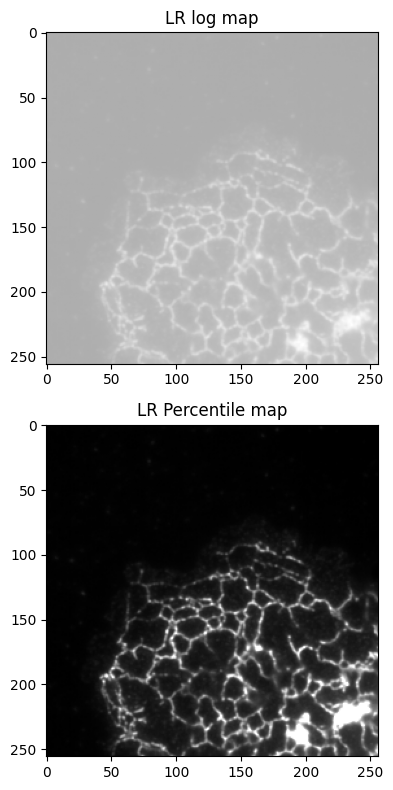

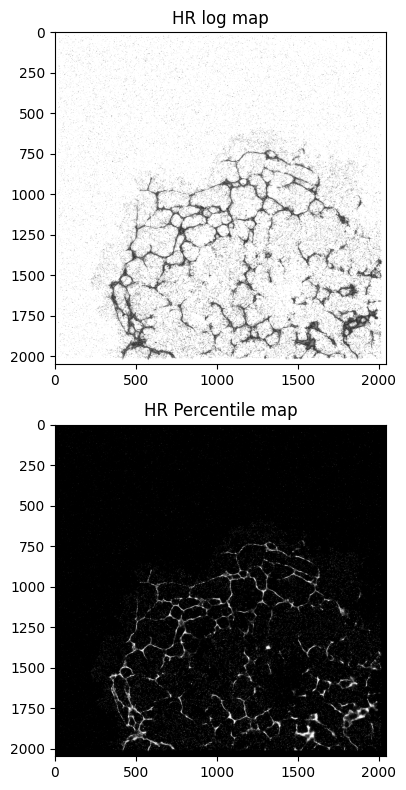

In [4]:
BATCH = 1
img_pairs = pd.read_csv(os.path.join(DSET_DIR,"img_pairs.csv"))
a = range(0,len(img_pairs))
train_index = random.sample(a, 110)
a = list(set(a) - set(train_index))
valid_index = random.sample(a, 10)
test_index = list(set(a) - set(valid_index)) 

lr = os.path.join(DSET_DIR, LR_DIR)
hr = os.path.join(DSET_DIR, HR_DIR)
#train
train_set = img_pairs.loc[train_index,:].reset_index(drop=True)
train_set = LRImgHRImgDataset(lr, hr, train_set)
train_ld = DataLoader(train_set, BATCH, pin_memory=can_cuda)
#valid
valid_set = img_pairs.loc[valid_index,:].reset_index(drop=True)
valid_set = LRImgHRImgDataset(lr, hr, valid_set)
valid_ld = DataLoader(valid_set, BATCH, pin_memory=can_cuda)
#test
test_set = img_pairs.loc[test_index,:].reset_index(drop=True)
test_set = LRImgHRImgDataset(lr, hr, test_set)
test_ld = DataLoader(test_set, BATCH, pin_memory=can_cuda)

#sanity check
fig, axes = plt.subplots(2,1, figsize=(6,8))
lr_ex = test_set[0][0].to('cpu').squeeze()
gt_ex = test_set[0][1].to('cpu').squeeze()
axes[0].imshow(lr_ex, norm=LogNorm(1, lr_ex.max()), cmap=CMAP)
axes[0].set_title("LR log map")
axes[1].imshow(lr_ex, vmin=np.percentile(lr_ex,1), vmax=np.percentile(lr_ex,99), cmap=CMAP)
axes[1].set_title("LR Percentile map")
plt.tight_layout()
fig, axes = plt.subplots(2,1, figsize=(6,8))
axes[0].imshow(gt_ex,norm=LogNorm(1,gt_ex.max()), cmap=CMAP)
axes[0].set_title("HR log map")
axes[1].imshow(gt_ex, vmin = np.percentile(gt_ex,1), vmax=np.percentile(gt_ex,99), cmap=CMAP)
axes[1].set_title("HR Percentile map")
plt.tight_layout()


plt.tight_layout()
print(f"Training images: {len(train_set)}")
print(f"Validation images: {len(valid_set)}")
print(f"Test images: {len(test_set)}")

In [5]:
model = DiffractionLimitedSRGAN(1, 1, 64, 32)
model = model.float()
LR_PATH = "./dset_out/lr_files"
HR_PATH = "./dset_out/hr_files"
EPOCHS = 20
MSE_FREQ_WARMUP = 10
gen_loss_fn = CompositeGenLoss(1,0.01,0)
gen_adv_loss = AdvLoss(0.1)
d_loss_fn = AdvLoss(1)
optimizer_gen = torch.optim.Adam(model.gen.parameters(), 0.0002, betas=(0.5,0.999))
optimizer_disc = torch.optim.Adam(model.discrim.parameters(), 0.0002)
    

def check_usage():
    print(f"Percent usage: {torch.cuda.memory_allocated(device)/torch.cuda.max_memory_allocated(device)}")

def do_loss_d(gen_out,hr):
    d_out_gen = model.discrim(gen_out)
    d_out_hr = model.discrim(hr)
    loss_dr, loss_df = d_loss_fn(d_out_gen, d_out_hr)
    loss = loss_dr + loss_df
    return loss

def do_loss_gen(gen_out, hr):
    d_out_gen = model.discrim(gen_out)
    d_out_hr = model.discrim(hr)
    loss_gr, loss_gf = gen_adv_loss(d_out_hr, d_out_gen)
    loss_g_gen = gen_loss_fn(gen_out, hr)
    loss = loss_gr + loss_gf + loss_g_gen
    return loss

model = model.to(device)
param_count = sum(p.numel() for p in model.parameters())
print(f"Approx model size: {param_count * 32/ (8*1000000)}GB")

def run_epoch(epoch_index, tb_writer=None):
    model.train()
    running_loss_g = 0
    running_loss_d = 0

    for i, data in enumerate(train_ld):
        if i %10 == 0:
            print(i)
        lr, hr = data
        lr = lr.to(device, non_blocking=True)
        hr = hr.to(device, non_blocking=True)
        if epoch_index > MSE_FREQ_WARMUP:
            optimizer_disc.zero_grad()
            g_out = model(lr)
            #contains backward call
            d_loss: torch.Tensor = do_loss_d(g_out.detach(), hr)
            d_loss.backward()
            optimizer_disc.step()
            optimizer_gen.zero_grad()
            g_out = model(lr)
            #contains backward call
            g_loss: torch.Tensor = do_loss_gen(g_out, hr)
            g_loss.backward()
            optimizer_gen.step()

            running_loss_d += d_loss.item()
            running_loss_g += g_loss.item()
        else:
            #pre-train/warmup to improve GAN results.
            optimizer_disc.zero_grad()
            optimizer_gen.zero_grad()
            g_out = model.gen(lr)
            g_loss = gen_loss_fn(g_out, hr)
            g_loss.backward()
            optimizer_gen.step()
            running_loss_g += g_loss.item()
            
    avg_loss_g = running_loss_g/len(train_ld)
    avg_loss_d = running_loss_d/len(train_ld)
    print(f"avg train gen loss: {avg_loss_g}")
    print(f"avg train disc loss: {avg_loss_d}")
    check_usage()

    with torch.no_grad():
        model.eval()
        g_vloss = 0
        d_vloss = 0
        for i, data in enumerate(valid_ld):
            lr, hr = data
            lr = lr.to(device, non_blocking=True)
            hr = hr.to(device, non_blocking=True)
            gen_out = model(lr)
            d_vloss += do_loss_d(gen_out, hr).item()
            g_vloss += do_loss_gen(gen_out, hr).item()
            
        g_vloss = g_vloss/len(valid_ld)
        d_vloss = d_vloss/len(valid_ld)
        print(f"Validation loss Gen: {g_vloss}, Disc: {d_vloss}")
        return g_vloss, d_vloss

def test_model():
    with torch.no_grad():
        model.eval()
        g_tloss = 0
        d_tloss = 0
        for i, data in enumerate(test_ld):
            lr, hr = data
            lr = lr.to(device, non_blocking=True)
            hr = hr.to(device, non_blocking=True)
            gen_out = model(lr)
            d_tloss = do_loss_d(gen_out, hr).item()
            g_tloss = do_loss_gen(gen_out, hr).item()
            

    g_tloss = g_tloss/len(valid_ld)
    d_tloss = d_tloss/len(valid_ld)
    print(f"Test loss Gen: {g_tloss}, Disc: {d_tloss}")
    return g_tloss, d_tloss

best_g = 1000000
best_d = 1000000
best_model = None

def save_best_model(current_loss, best_loss, label, model):
    if current_loss < best_loss:
        best_loss = current_loss
        print(f"Best loss: {current_loss}, from: {label}")
        torch.save(model.state_dict(), f"./best_params/{label}.pth")
        return label


for epoch in range(0,EPOCHS):
    print(f"Epoch: {epoch}")
    ts = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M")
    labelG = f"GModel-{ts}-l"
    labelD = f"DModel-{ts}-l"
    g_loss, d_loss = run_epoch(epoch)
    best_g_label = save_best_model(g_loss, best_g, labelG, model.gen)
    best_d_label = save_best_model(d_loss, best_d, labelD, model.discrim)

Approx model size: 8.1453GB
Epoch: 0
0
10
20
30
40
50
60
70
80
90
100
avg train gen loss: 494728.0553267045
avg train disc loss: 0.0
Percent usage: 0.009392618727956221
Validation loss Gen: 193593.10078125, Disc: 0.9999945223331451
Best loss: 193593.10078125, from: GModel-2026-07-15-15-57-l
Best loss: 0.9999945223331451, from: DModel-2026-07-15-15-57-l
Epoch: 1
0
10
20
30
40
50
60
70
80
90
100
avg train gen loss: 138022.1572088068
avg train disc loss: 0.0
Percent usage: 0.009392618727956221
Validation loss Gen: 114152.435546875, Disc: 0.9999993145465851
Best loss: 114152.435546875, from: GModel-2026-07-15-16-04-l
Best loss: 0.9999993145465851, from: DModel-2026-07-15-16-04-l
Epoch: 2
0
10
20
30
40
50
60
70
80
90
100
avg train gen loss: 105461.88004261363
avg train disc loss: 0.0
Percent usage: 0.009392618727956221
Validation loss Gen: 104887.47578125, Disc: 0.9999994814395905
Best loss: 104887.47578125, from: GModel-2026-07-15-16-06-l
Best loss: 0.9999994814395905, from: DModel-2026-07

Unnamed: 0                43
lr_name       ER-KDEL_c23_LR
hr_name       ER-KDEL_c23_HR
Name: 2, dtype: object


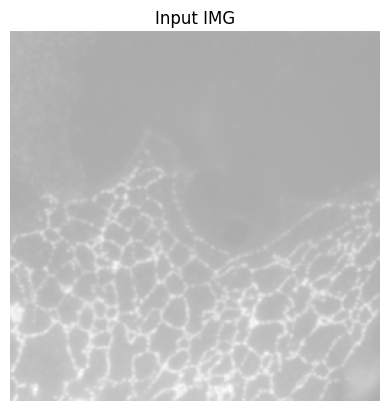

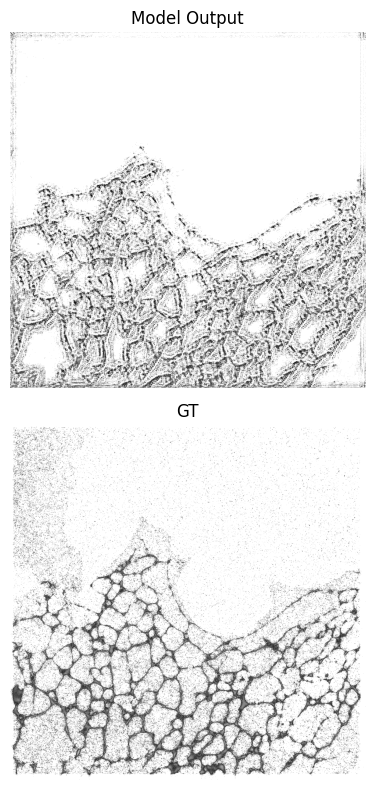

In [7]:
model = RRDB_Generator(1, 64, 32, True, 0.2, 1)
model = model.to(device)
model.load_state_dict(torch.load(r"./best_params/" + "GModel-2026-07-15-16-42-l" + ".pth"))
loss_fn = nn.MSELoss()
#testing SR capabilities
#take a test image, SR it, and compare to GT
test_in, test_gt = test_set[2]
test_in = test_in.to(device, non_blocking=True)
test_gt = test_gt.to(device, non_blocking=True)
print(test_set.img_pairs.loc[2,:])
test_in = test_in.unsqueeze(0)
out = model(test_in)
ax = plt.axes()
out = out.to('cpu')
out = out.squeeze()
out = out.detach().numpy()
#comparisons (visual)
test_in = test_in.to('cpu').squeeze()
ax.imshow(test_in, norm=LogNorm(1, test_in.max()), cmap=CMAP)
ax.set_title("Input IMG")
ax.set_axis_off()
gt = test_gt.to('cpu').squeeze()
gt = gt.detach().numpy()
fig, axes = plt.subplots(2,1, figsize=(5,8))
axes[0].imshow(out, norm=LogNorm(1, out.max()), cmap=CMAP)
axes[0].set_title("Model Output")
axes[0].set_axis_off()
axes[1].imshow(gt, norm=LogNorm(1, gt.max()), cmap=CMAP)
axes[1].set_title("GT")
axes[1].set_axis_off()
plt.tight_layout()